In [1]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium shimmy

In [2]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random
import pickle

import gymnasium as gym
from gymnasium import spaces
from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from collections import deque
from tensorflow import keras
from tensorflow.keras import layers, optimizers, models
from scipy.signal import find_peaks

pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [4]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 2 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [5]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [6]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                train_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                return train_df
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [7]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [8]:
train_df = fetch_candle_data(100)

#train_df = fetch_train_candle_data(25)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

13003
12815


In [9]:
class DataProcessor:
    def __init__(self, train_df, peak_length=14, indicator_length=14, live_processing=False):
        """
        Initialize the DataProcessor with separate lengths for peak detection and indicators.
        :param train_df: Input DataFrame with OHLC data.
        :param peak_length: Length used for peak detection (support/resistance).
        :param indicator_length: Length used for technical indicators.
        """
        self.train_df = train_df.copy()
        self.peak_length = peak_length  # Length for support and resistance peaks
        self.indicator_length = indicator_length  # Length for indicators like RSI, EMA, ATR
        self.live_processing = live_processing # Enable or disable live processing

    def preprocess_datetime(self):
        """
        Preprocess the datetime column: convert to IST and handle duplicates or missing values.
        """
        ist = timezone('Asia/Kolkata')
        self.train_df['datetime'] = pd.to_datetime(self.train_df['datetime'], unit='s')
        self.train_df['datetime'] = (
            self.train_df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.train_df['datetime'].duplicated().any() or self.train_df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.train_df.set_index(self.train_df['datetime'], inplace=True)
        self.train_df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        """
        Handle volume column and remove rows with missing or zero values.
        """
        if 'volume' in self.train_df.columns:
            self.train_df['volume'] = self.train_df['volume'].fillna(0)
            if (self.train_df['volume'] == 0).all() or self.train_df['volume'].isnull().all():
                self.train_df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        return self

    def add_indicators(self):
        """
        Add technical indicators dynamically based on the provided indicator length.
        """
        self.train_df['rsi'] = ta.rsi(self.train_df['close'], length=self.indicator_length)
        self.train_df['ema'] = ta.ema(self.train_df['close'], length=self.indicator_length)
        self.train_df['atr'] = ta.atr(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)

        bbands = ta.bbands(self.train_df['close'], length=self.indicator_length)
        self.train_df['bb_upper'] = bbands['BBU_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_middle'] = bbands['BBM_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_lower'] = bbands['BBL_' + str(self.indicator_length) + '_2.0']

        self.train_df['hv'] = self.train_df['close'].pct_change().rolling(self.indicator_length).std() * (252 ** 0.5)
        self.train_df['price_spread'] = (self.train_df['close'] - self.train_df['open']) / (
            self.train_df['high'] - self.train_df['low'])
        self.train_df['candle_to_atr'] = (self.train_df['high'] - self.train_df['low']) / self.train_df['atr']
        self.train_df['hour'] = self.train_df.index.hour
        self.train_df['day_of_week'] = self.train_df.index.dayofweek
        self.train_df['roc'] = ta.roc(self.train_df['close'], length=self.indicator_length)
        self.train_df['price_change'] = self.train_df['close'].diff()
        self.train_df['Target'] = self.train_df['atr'] * 2
        self.train_df['Stop Loss'] = self.train_df['atr']
        return self

    def calculate_support_resistance(self):
        """
        Calculate support and resistance levels using peaks detection with separate peak_length.
        """
        resistance_peaks, _ = find_peaks(self.train_df['high'], distance=self.peak_length)
        self.train_df['resistance'] = 0.0
        self.train_df.loc[self.train_df.index[resistance_peaks], 'resistance'] = self.train_df['high'].iloc[resistance_peaks]

        support_peaks, _ = find_peaks(-self.train_df['low'], distance=self.peak_length)
        self.train_df['support'] = 0.0
        self.train_df.loc[self.train_df.index[support_peaks], 'support'] = self.train_df['low'].iloc[support_peaks]
        return self

    def detect_market_conditions(self):
        """
        Add features to detect market conditions (trending, range-bound, or volatile).
        """
        adx = ta.adx(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)
        self.train_df['adx'] = adx['ADX_' + str(self.indicator_length)]

        self.train_df['rsi_oscillation'] = ((self.train_df['rsi'] > 40) & (self.train_df['rsi'] < 60)).astype(int)

        self.train_df['compression_ratio'] = self.train_df['atr'] / (
            self.train_df['high'].rolling(self.indicator_length).max()
            - self.train_df['low'].rolling(self.indicator_length).min()
        )
        return self

    def detect_market_regime(self):
        """
        Efficiently detect market regimes and assign integer labels:
        0 - Sideways, 1 - Trending, 2 - Volatile
        """
        self.train_df['market_regime'] = 0

        trending_threshold = 25
        self.train_df.loc[self.train_df['adx'] > trending_threshold, 'market_regime'] = 1

        self.train_df.loc[
            (self.train_df['bb_upper'] - self.train_df['bb_lower']) / self.train_df['bb_middle'] > 0.05,
            'market_regime'
        ] = 2
        return self

    def label_signals(self):
        """
        Generate buy/sell signals based on target and stop-loss levels.
        """
        self.train_df['Signal'] = 0
        self.train_df['Entry Price'] = 0.0
        self.train_df['Exit Price'] = 0.0

        for i in range(len(self.train_df)):
            entry_price = self.train_df['close'].iloc[i]

            target = self.train_df['Target'].iloc[i]
            stop_loss = self.train_df['Stop Loss'].iloc[i]

            buy_target_price = entry_price + target
            buy_sl_price = entry_price - stop_loss

            sell_target_price = entry_price - target
            sell_sl_price = entry_price + stop_loss

            future_data = self.train_df.iloc[i + 1:]

            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_high >= buy_target_price:
                    self.train_df.at[self.train_df.index[i], 'Signal'] = 1 #Buy Signal
                    self.train_df.at[self.train_df.index[i], 'Entry Price'] = entry_price
                    self.train_df.at[self.train_df.index[i], 'Exit Price'] = future_high
                    break
                elif future_low <= buy_sl_price:
                    break

            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_low <= sell_target_price:
                    self.train_df.at[self.train_df.index[i], 'Signal'] = 2 #Sell Signal
                    self.train_df.at[self.train_df.index[i], 'Entry Price'] = entry_price
                    self.train_df.at[self.train_df.index[i], 'Exit Price'] = future_low
                    break
                elif future_high >= sell_sl_price:
                    break
        return self

    def process(self):
        """
        Chain all preprocessing steps together.
        """
        self.preprocess_datetime()
        self.clean_data()
        self.add_indicators()
        self.calculate_support_resistance()
        self.detect_market_conditions()
        self.detect_market_regime()

        if self.live_processing:
            return self.finalize()

        self.label_signals()
        return self.finalize()

    def finalize(self):
        """
        Finalize the dataset by dropping rows with NaN values in any column and converting data types.
        """

        self.train_df = self.train_df[[col for col in self.train_df.columns if col not in ['Entry Price', 'Exit Price']]]

        self.train_df.dropna(inplace=True)

        feature_columns = [
            col for col in self.train_df.columns if col not in ['Target', 'Stop Loss']
        ]
        self.train_df[feature_columns] = self.train_df[feature_columns].astype(float).round(2)
        self.train_df['Target'] = self.train_df['Target'].astype(int)
        self.train_df['Stop Loss'] = self.train_df['Stop Loss'].astype(int)
        return self


# Usage
data_processor = DataProcessor(train_df, peak_length=100, indicator_length=14)
processed_df = data_processor.process().train_df

processed_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,...,price_change,Target,Stop Loss,resistance,support,adx,rsi_oscillation,compression_ratio,market_regime,Signal
datetime,,,,,,,,,,,,,,,,,,,,,
2024-09-25 10:09:00,53977.20,53977.50,53942.35,53956.15,46.58,53981.24,36.77,54023.57,53990.89,53958.21,...,-18.15,73,36,0.00,0.0,30.13,1.0,0.42,1.0,1.0
2024-09-25 10:11:00,53959.55,53973.00,53949.00,53973.00,51.16,53980.14,35.73,54023.78,53989.84,53955.90,...,16.85,71,35,0.00,0.0,27.19,1.0,0.40,1.0,1.0
2024-09-25 10:13:00,53973.65,53974.30,53940.35,53953.75,46.28,53976.62,35.58,54023.85,53986.24,53948.64,...,-19.25,71,35,0.00,0.0,24.91,1.0,0.39,0.0,1.0
2024-09-25 10:15:00,53955.40,53970.05,53949.60,53960.00,48.01,53974.41,34.37,54024.03,53984.15,53944.26,...,6.25,68,34,0.00,0.0,22.93,1.0,0.38,0.0,1.0
2024-09-25 10:17:00,53958.10,53989.30,53958.10,53987.30,54.87,53976.12,34.12,54020.93,53982.82,53944.72,...,27.30,68,34,0.00,0.0,21.83,1.0,0.43,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-03 15:21:00,51002.75,51013.55,50985.55,50992.60,46.81,50996.41,42.13,51063.63,50993.70,50923.77,...,-9.40,84,42,51013.55,0.0,23.32,1.0,0.24,0.0,0.0
2025-01-03 15:23:00,50993.55,50993.55,50951.15,50955.55,42.15,50990.96,42.15,51048.88,50986.38,50923.87,...,-37.05,84,42,0.00,0.0,22.98,1.0,0.26,0.0,0.0
2025-01-03 15:25:00,50949.20,50969.05,50949.20,50955.15,42.10,50986.19,40.55,51033.45,50979.68,50925.91,...,-0.40,81,40,0.00,0.0,22.72,1.0,0.27,0.0,0.0


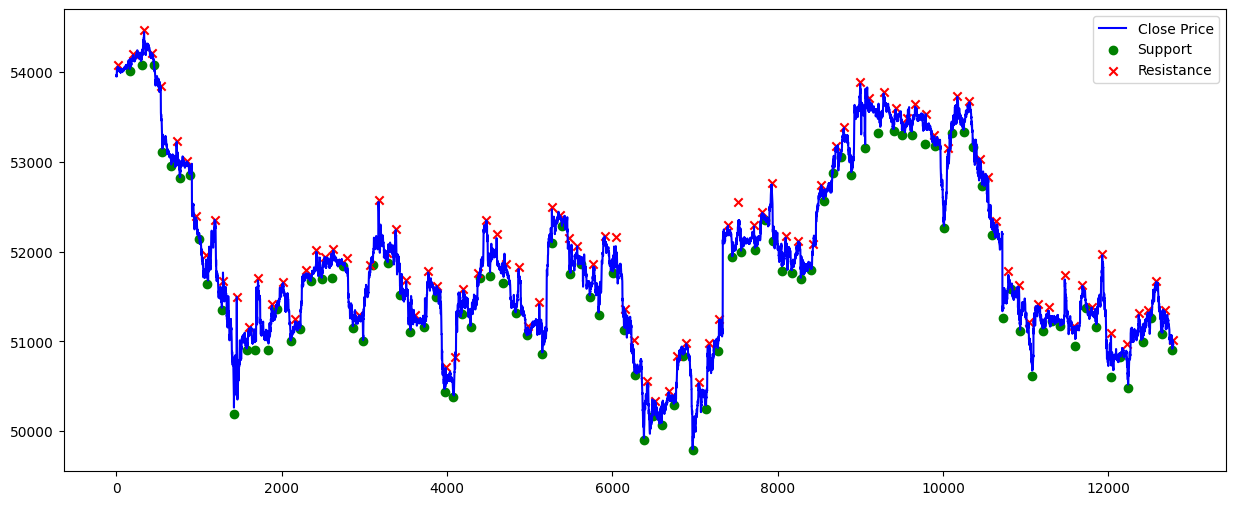

In [10]:
# Create a copy of the support and resistance columns to avoid modifying the original DataFrame
support_filtered = processed_df['support'].replace(0.0, float('nan'))
resistance_filtered = processed_df['resistance'].replace(0.0, float('nan'))

# Create a larger figure
plt.figure(figsize=(15, 6))

# Plot the close price using the range of data for the x-axis
plt.plot(range(len(processed_df)), processed_df['close'], label='Close Price', color='blue')

# Plot the support and resistance points, excluding 0/0.0 values
plt.scatter(range(len(processed_df)), support_filtered, label='Support', color='green', marker='o')
plt.scatter(range(len(processed_df)), resistance_filtered, label='Resistance', color='red', marker='x')

# Add legend and show plot
plt.legend()
plt.show()

In [14]:
class TradingEnvironment(gym.Env):
    def __init__(self, data, config):
        super(TradingEnvironment, self).__init__()
        self.data = data.to_numpy()
        self.columns = data.columns.tolist()

        # Remove the 'Signal' column for observations
        if 'Signal' in self.columns:
            self.signal_idx = self.columns.index('Signal')
            self.columns.remove('Signal')  # Exclude 'Signal' from columns
        else:
            self.signal_idx = None

        self.config = config
        self.window_size = config['window_size']
        self.current_step = 0
        self.done = False
        self.balance = float(config['initial_capital'])
        self.quantity = config['quantity']
        self.position = 0
        self.entry_price = 0.0
        self.target_price = 0.0
        self.stop_loss_price = 0.0
        self.brokerage = config['brokerage']
        self.trades_log = []
        self.trades = []
        self.holding_duration = 0
        self.rewards = []
        self.profit_streak = 0
        self.loss_streak = 0

        # Action Space: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)

        # Observation Space: Flattened data window
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.window_size, len(self.columns)), dtype=np.float32
        )


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.done = False
        self.balance = float(self.config['initial_capital'])
        self.position = 0
        self.entry_price = 0.0
        self.target_price = 0.0
        self.stop_loss_price = 0.0
        self.trades_log = []
        self.trades = []
        self.holding_duration = 0
        self.rewards = []
        self.profit_streak = 0
        self.loss_streak = 0
        return self._get_state(), {}

    def _get_state(self):
        state = self.data[self.current_step - self.window_size:self.current_step]
        if self.signal_idx is not None:
            state = np.delete(state, self.signal_idx, axis=1)  # Remove 'Signal' column dynamically
        return state

    def step(self, action):
        price = self.data[self.current_step, self.columns.index('close')]
        target_points = self.data[self.current_step, self.columns.index('Target')]
        stop_loss_points = self.data[self.current_step, self.columns.index('Stop Loss')]
        signal = self.data[self.current_step, self.signal_idx] if self.signal_idx is not None else None
        reward = 0.0
        profit_loss = 0.0

        # Handle open positions
        if self.position != 0:
            self.holding_duration += 1
            if (self.position == 1 and price >= self.target_price) or (self.position == -1 and price <= self.target_price):
                captured_points = abs(self.target_price - self.entry_price)
                profit_loss = captured_points * self.quantity
                self.balance += profit_loss  # Add profit to balance
                reward += 2.0  # Reward for hitting the target
                self.profit_streak += 1
                self.loss_streak = 0
                reward *= (1 + 0.1 * self.profit_streak)  # Multiply reward for profit streak
                self._log_trade(price, "Target Hit")
                self.position = 0
                self.holding_duration = 0

            elif (self.position == 1 and price <= self.stop_loss_price) or (self.position == -1 and price >= self.stop_loss_price):
                captured_points = abs(self.entry_price - self.stop_loss_price)
                profit_loss = -captured_points * self.quantity
                self.balance += profit_loss  # Subtract loss from balance
                reward -= 1.0  # Penalty for hitting stop loss
                self.loss_streak += 1
                self.profit_streak = 0
                reward *= (1 - 0.1 * self.loss_streak)  # Multiply penalty for loss streak
                self._log_trade(price, "Stop Loss Hit")
                self.position = 0
                self.holding_duration = 0

        # Handle new actions
        if self.position == 0:
            if action == 1:  # Buy
                self.position = 1
                self.entry_price = price
                self.target_price = price + target_points
                self.stop_loss_price = price - stop_loss_points

                if signal == 1:
                    reward += 1.5
                else:
                    reward -= 0.75

            elif action == 2:  # Sell
                self.position = -1
                self.entry_price = price
                self.target_price = price - target_points
                self.stop_loss_price = price + stop_loss_points

                if signal == 2:
                    reward += 1.5
                else:
                    reward -= 0.75

            elif action == 0: # Hold
                if signal == 1 or signal == 2:
                    reward -= 0.5

        # Penalize overtrading or revenge trading
        if len(self.trades_log) > 1:
            last_trade = self.trades_log[-1]
            if last_trade['Status'] in ["Stop Loss Hit", "Target Hit"]:
                time_since_last_trade = self.current_step - last_trade['Exit Step']
                if time_since_last_trade < self.config['min_trade_gap']:
                    reward -= 0.2  # Penalty for revenge trading

        # Update simulation
        self.current_step += 1
        if self.current_step >= len(self.data) or self.balance <= 0:
            self.done = True

        self.rewards.append(reward)
        info = {
            'Entry Price': self.entry_price,
            'Current Price': price,
            'Target Price': f"{self.target_price} ({target_points})",
            'Stop Loss Price': f"{self.stop_loss_price} ({stop_loss_points})",
            'Holding Duration': self.holding_duration,
            'Position': self.position,
            'Profit Streak': self.profit_streak,
            'Loss Streak': self.loss_streak,
            'Balance': self.balance,
            'Profit/Loss': profit_loss,
            'Reward': reward,
        }
        return self._get_state(), reward, self.done, False, info

    def _log_trade(self, price, status):
        self.trades_log.append({
            'Entry Price': self.entry_price,
            'Exit Price': price,
            'Target Price': self.target_price,
            'Stop Loss Price': self.stop_loss_price,
            'Holding Duration': self.holding_duration,
            'Status': status,
            'Exit Step': self.current_step
        })

    def get_trade_logs(self):
        return pd.DataFrame(self.trades_log)

    def calculate_metrics(self):
        sharpe_ratio = 0.0
        profit_factor = 0.0
        win_rate = 0.0

        if (len(self.trades_log) > 0):
            pnl = [t['Exit Price'] - t['Entry Price'] if t['Status'] == "Target Hit" else t['Entry Price'] - t['Exit Price'] for t in self.trades_log]
            pnl = np.array(pnl)

            # Sharpe Ratio
            mean_return = np.mean(pnl)
            std_return = np.std(pnl)
            sharpe_ratio = mean_return / std_return if std_return != 0 else 0

            # Profit Factor
            gross_profit = np.sum(pnl[pnl > 0])
            gross_loss = np.sum(-pnl[pnl < 0])
            profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf

            # Win Rate
            wins = sum([1 for t in self.trades_log if t['Status'] == "Target Hit"])
            total_trades = len(self.trades_log)
            win_rate = (wins / total_trades) * 100 if total_trades > 0 else 0



        return {
            "Sharpe Ratio": sharpe_ratio,
            "Profit Factor": profit_factor,
            "Win Rate": win_rate
        }

    def print_trade_summary(self):
        metrics = self.calculate_metrics()
        print(f"\nFinal Balance: {self.balance:.2f}")
        print(f"Total Trades: {len(self.trades_log)}")
        print(f"Profitable Trades: {sum([1 for t in self.trades_log if t['Status'] == 'Target Hit'])}")
        print(f"Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}")
        print(f"Profit Factor: {metrics['Profit Factor']:.2f}")
        print(f"Win Rate: {metrics['Win Rate']:.2f}%")

    def render(self, mode='human'):
        print(f"Step: {self.current_step}, Balance: {self.balance:.2f}, Position: {self.position}")

    def close(self):
        pass

In [15]:
# Configuration
config = {
    'window_size': 10,
    'initial_capital': 10000,
    'quantity': quantity,
    'min_trade_gap': 2,
    'brokerage': 20,
}

# Check for GPU availability and set memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        device = '/GPU:0'
    except RuntimeError as e:
        print(e)
else:
    device = '/CPU:0'
print(f"Training will use {'GPU' if gpus else 'CPU'}.")

Training will use GPU.


Version 1

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

env = DummyVecEnv([lambda: TradingEnvironment(processed_df, config)])

model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=10000)

Using cuda device
-----------------------------
| time/              |      |
|    fps             | 651  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 508         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011533552 |
|    clip_fraction        | 0.0118      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.00532    |
|    learning_rate        | 0.0003      |
|    loss                 | 1.55        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0008     |
|    value_loss           | 3.18        |
-----------------------------------------


In [ ]:
# Evaluation
test_env = TradingEnvironment(processed_df, config)
obs, _ = test_env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = test_env.step(action)
    test_env.render()

In [ ]:
test_env.print_trade_summary()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
import time

def visualize_trades_matplotlib(env, data):
    trades = env.get_trade_logs()
    close_prices = data['close'].values

    # Initialize the figure and axis
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot for the price line
    line, = ax.plot([], [], label='Close Price', color='blue')

    # Entry and exit markers
    entry_marker, = ax.plot([], [], 'o', color='orange', markersize=8, label='Entry')
    target_marker, = ax.plot([], [], '^', color='green', markersize=10, label='Target Hit')
    stop_loss_marker, = ax.plot([], [], 'v', color='red', markersize=10, label='Stop Loss Hit')

    # Set axis labels
    ax.set_title('Trade Visualization on Closing Price Chart')
    ax.set_xlabel('Steps')
    ax.set_ylabel('Price')

    # Add a legend
    ax.legend()

    # Set initial limits for the axes
    ax.set_xlim(0, 100)
    ax.set_ylim(np.min(close_prices) * 0.95, np.max(close_prices) * 1.05)

    # Update the plot dynamically
    for step in range(100, len(close_prices) + 1):
        # Update price line
        line.set_xdata(np.arange(step))
        line.set_ydata(close_prices[:step])

        # Add trade details dynamically
        entry_x, entry_y = [], []
        target_x, target_y = [], []
        stop_loss_x, stop_loss_y = [], []
        path_x, path_y = [], []
        path_colors = []  # List to store colors for each trade path

        for _, trade in trades.iterrows():
            entry_step = trade['Exit Step'] - trade['Holding Duration']
            exit_step = trade['Exit Step']

            if exit_step > step:
                continue

            # Collect entry points
            if entry_step <= step:
                entry_x.append(entry_step)
                entry_y.append(close_prices[entry_step])

            # Collect exit points
            if exit_step <= step:
                if trade['Status'] == 'Target Hit':
                    target_x.append(exit_step)
                    target_y.append(close_prices[exit_step])
                elif trade['Status'] == 'Stop Loss Hit':
                    stop_loss_x.append(exit_step)
                    stop_loss_y.append(close_prices[exit_step])

                # Add path points
                path_x.extend([entry_step, exit_step, None])
                path_y.extend([close_prices[entry_step], close_prices[exit_step], None])

                # Determine the path color based on the trade outcome
                if trade['Status'] == 'Target Hit':  # Profit
                    path_colors.extend(['green', 'green', 'none'])
                elif trade['Status'] == 'Stop Loss Hit':  # Loss
                    path_colors.extend(['red', 'red', 'none'])

        # Update entry, target, stop loss markers
        entry_marker.set_xdata(entry_x)
        entry_marker.set_ydata(entry_y)

        target_marker.set_xdata(target_x)
        target_marker.set_ydata(target_y)

        stop_loss_marker.set_xdata(stop_loss_x)
        stop_loss_marker.set_ydata(stop_loss_y)

        # Update trade paths with dynamic colors
        for i in range(0, len(path_x), 3):
            ax.plot(path_x[i:i+2], path_y[i:i+2], color=path_colors[i], linestyle='--')

        # Adjust the visible range dynamically
        visible_close_prices = close_prices[max(0, step - 100):step]

        # Update y-axis range based on the current visible close prices
        y_min = np.min(visible_close_prices) * 1  # Tightened buffer around min price
        y_max = np.max(visible_close_prices) * 1  # Tightened buffer around max price

        # Update y-axis range dynamically, ensuring tighter scaling
        ax.set_ylim(y_min, y_max)

        # Update x-axis range to be consistent with visible steps
        ax.set_xlim(max(0, step - 100), step)

        # Display the updated chart
        clear_output(wait=True)
        display(fig)
        time.sleep(0.001)

# Example usage
visualize_trades_matplotlib(test_env, processed_df)